# Practice Tutorial Using Astronomical Dataset

After running through the tutorial, I'll be taking astronomical dataset with a timeseries ('age') to 

Some errors I should watch out for: 
1) Is it time-series/can I make it into time series? I'll start off by checking if this dataset has columns, like age, I can work with. 
2) Am I choosing the right variables to map? In broader terms, do I have a clear question that the dataset can answer? Do I have a question that can best, keyword best, by answered by sonified data? What variables do I need or don't need? 
3) Do I have the right libraries installed? From now on, I should spend the rest of the week setting up a venv to make it easier to manage this project without running into issues with libraries

## Load Data 

I'll start off by loading the asteroid.csv dataset

In [152]:
import pandas as pd
import matplotlib.pylab as plt
import numpy as np
import seaborn as sns
from scipy import stats

file = 'map_object_list.csv' 

pre_df = pd.read_csv(file)
df = pre_df.dropna(subset=['log10 age (years)'])
df = df.drop('Arm (masers)', axis = 1)

df = df.sort_values(by=['log10 age (years)'], ascending = False)
df = df[df['log10 age (years)'] != 'unknown'] 
df['log10 age (years)'] = df['log10 age (years)'].astype(float)
df.rename(columns = {'glon': 'Longitude', 'glat': 'Latitude'}, inplace=True)


#df['log10 age (years)'] = (10 ** df['log10 age (years)'])
#df.rename(columns={'log10 age (years)': 'age (years)'}, inplace =True)


df.head()
#df.tail()



,type,name,Longitude,Latitude,distance (parsecs),x (parsecs),y (parsecs),z (parsecs),radius (parsecs),log10 age (years),Source
295,open cluster,Berkeley_20,203.485,-17.377,14402.1,-12606.234754,-5477.423053,-4301.298228,3.770461,9.78,2020A&A...633A..99C
300,open cluster,Berkeley_25,226.613,-9.629,9467.7,-6411.951824,-6783.531358,-1583.641187,3.139608,9.70,2020A&A...633A..99C
1025,open cluster,NGC_6253,335.459,-6.257,1689.7,1527.903532,-697.626604,-184.157566,1.769450,9.70,2020A&A...633A..99C
742,open cluster,King_1,119.758,1.692,1825.1,-905.471013,1583.732369,53.889142,4.937383,9.70,2020A&A...633A..99C
387,open cluster,Collinder_261,301.696,-5.537,2903.7,1518.521069,-2459.079121,-280.173748,5.473352,9.70,2020A&A...633A..99C


In [153]:
df.nunique()

type                     1
name                  1398
Longitude             1395
Latitude              1324
distance (parsecs)    1371
x (parsecs)           1398
y (parsecs)           1398
z (parsecs)           1398
radius (parsecs)      1398
log10 age (years)      448
Source                   2
dtype: int64

Seems like the only cosmic structure type I could work with are open clusters, since the ages of those cosmic objects have been collected while there doesn't seem to be info on ages for masers and HII Regions. 

In [154]:
df.isnull().sum()

type                  0
name                  0
Longitude             0
Latitude              0
distance (parsecs)    0
x (parsecs)           0
y (parsecs)           0
z (parsecs)           0
radius (parsecs)      0
log10 age (years)     0
Source                2
dtype: int64

In [155]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1398 entries, 295 to 471
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   type                1398 non-null   object 
 1   name                1398 non-null   object 
 2   Longitude           1398 non-null   float64
 3   Latitude            1398 non-null   float64
 4   distance (parsecs)  1398 non-null   float64
 5   x (parsecs)         1398 non-null   float64
 6   y (parsecs)         1398 non-null   float64
 7   z (parsecs)         1398 non-null   float64
 8   radius (parsecs)    1398 non-null   float64
 9   log10 age (years)   1398 non-null   float64
 10  Source              1396 non-null   object 
dtypes: float64(8), object(3)
memory usage: 131.1+ KB


In [156]:
from sklearn.preprocessing import PowerTransformer 

pt = PowerTransformer('yeo-johnson', standardize = True)
df['distance (parsecs)'] = pt.fit_transform(df[['distance (parsecs)']])
df.head()

,type,name,Longitude,Latitude,distance (parsecs),x (parsecs),y (parsecs),z (parsecs),radius (parsecs),log10 age (years),Source
295,open cluster,Berkeley_20,203.485,-17.377,3.044584,-12606.234754,-5477.423053,-4301.298228,3.770461,9.78,2020A&A...633A..99C
300,open cluster,Berkeley_25,226.613,-9.629,2.269704,-6411.951824,-6783.531358,-1583.641187,3.139608,9.70,2020A&A...633A..99C
1025,open cluster,NGC_6253,335.459,-6.257,-0.233438,1527.903532,-697.626604,-184.157566,1.769450,9.70,2020A&A...633A..99C
742,open cluster,King_1,119.758,1.692,-0.141407,-905.471013,1583.732369,53.889142,4.937383,9.70,2020A&A...633A..99C
387,open cluster,Collinder_261,301.696,-5.537,0.448931,1518.521069,-2459.079121,-280.173748,5.473352,9.70,2020A&A...633A..99C


In [157]:
pt = PowerTransformer('yeo-johnson', standardize = True)
df['x (parsecs)'] = pt.fit_transform(df[['x (parsecs)']])
df.head()

,type,name,Longitude,Latitude,distance (parsecs),x (parsecs),y (parsecs),z (parsecs),radius (parsecs),log10 age (years),Source
295,open cluster,Berkeley_20,203.485,-17.377,3.044584,-5.474881,-5477.423053,-4301.298228,3.770461,9.78,2020A&A...633A..99C
300,open cluster,Berkeley_25,226.613,-9.629,2.269704,-2.769523,-6783.531358,-1583.641187,3.139608,9.70,2020A&A...633A..99C
1025,open cluster,NGC_6253,335.459,-6.257,-0.233438,1.024538,-697.626604,-184.157566,1.769450,9.70,2020A&A...633A..99C
742,open cluster,King_1,119.758,1.692,-0.141407,-0.312454,1583.732369,53.889142,4.937383,9.70,2020A&A...633A..99C
387,open cluster,Collinder_261,301.696,-5.537,0.448931,1.018814,-2459.079121,-280.173748,5.473352,9.70,2020A&A...633A..99C


In [158]:
pt = PowerTransformer('yeo-johnson', standardize = True)
df['z (parsecs)'] = pt.fit_transform(df[['z (parsecs)']])
df.head()

,type,name,Longitude,Latitude,distance (parsecs),x (parsecs),y (parsecs),z (parsecs),radius (parsecs),log10 age (years),Source
295,open cluster,Berkeley_20,203.485,-17.377,3.044584,-5.474881,-5477.423053,-14.160173,3.770461,9.78,2020A&A...633A..99C
300,open cluster,Berkeley_25,226.613,-9.629,2.269704,-2.769523,-6783.531358,-5.339945,3.139608,9.70,2020A&A...633A..99C
1025,open cluster,NGC_6253,335.459,-6.257,-0.233438,1.024538,-697.626604,-0.638870,1.769450,9.70,2020A&A...633A..99C
742,open cluster,King_1,119.758,1.692,-0.141407,-0.312454,1583.732369,0.254713,4.937383,9.70,2020A&A...633A..99C
387,open cluster,Collinder_261,301.696,-5.537,0.448931,1.018814,-2459.079121,-0.971843,5.473352,9.70,2020A&A...633A..99C


In [159]:
pt = PowerTransformer('yeo-johnson', standardize = True)
df['log10 age (years)'] = pt.fit_transform(df[['log10 age (years)']])
df.head()

,type,name,Longitude,Latitude,distance (parsecs),x (parsecs),y (parsecs),z (parsecs),radius (parsecs),log10 age (years),Source
295,open cluster,Berkeley_20,203.485,-17.377,3.044584,-5.474881,-5477.423053,-14.160173,3.770461,2.603175,2020A&A...633A..99C
300,open cluster,Berkeley_25,226.613,-9.629,2.269704,-2.769523,-6783.531358,-5.339945,3.139608,2.414477,2020A&A...633A..99C
1025,open cluster,NGC_6253,335.459,-6.257,-0.233438,1.024538,-697.626604,-0.638870,1.769450,2.414477,2020A&A...633A..99C
742,open cluster,King_1,119.758,1.692,-0.141407,-0.312454,1583.732369,0.254713,4.937383,2.414477,2020A&A...633A..99C
387,open cluster,Collinder_261,301.696,-5.537,0.448931,1.018814,-2459.079121,-0.971843,5.473352,2.414477,2020A&A...633A..99C


## Part 2: Plot data and Figure out mapping Parameters 

Now that I've cleaned up the data and have a fully functioning age column, I can start plotting the data to visualize what my data currently looks like. 

Before that, I want to figure out what parameters I want to measure: 
1) x-axis is obviously age: Time series 
2) y-axis could be distance? This feels like a risk, but I might as well try. 
3) I'll scale by size of the cosmic structure. 

NOTE: DISTRIBUTIONS HAVE BEEN CHECKED AND TRANSFORMATIONS (YEO-JOHNSON) HAS BEEN PERFORMED

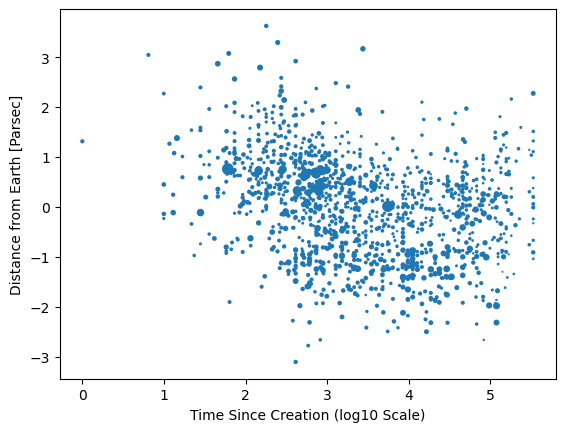

In [160]:
import matplotlib.pylab as plt 

ages = df['log10 age (years)'].values 
distances = df['distance (parsecs)'].values 
radius = df['radius (parsecs)'].values 

years_ago = max(ages) - ages

plt.scatter(years_ago, distances, s=radius)
plt.xlabel('Time Since Creation (log10 Scale)')
plt.ylabel('Distance from Earth [Parsec]')
plt.show()


## Part 3: Write a Mapping Function

Most likely, the purpose of a mapping section is to identify the relationship between the relative distance of a dataset in comparison to the absolute distance. Try to understand what the code from the tutorial represents. 

In [161]:
def mapping_function(value, min_value, max_value, min_result, max_result):
    result = min_result + (value - min_value)/(max_value - min_value)*(max_result - min_result)
    return result 

## Part 4: Compress Time

We can use the mapping function we created in Part 3 to start compressing time and create an ideal length for our song. 



In [162]:
"""I'm going to go with option 2 and focus on setting duration without focusing on rescaling to millions of years"""

duration_beats = 200.0

t_data = mapping_function(years_ago, 0, max(years_ago), 0, duration_beats)

age_per_beat = max(years_ago)/duration_beats
print('Age per beat:', age_per_beat)

#The printed value is a really odd value to get. I'll stick with the value I have right now, but if the midi file sounds odd, then I'll have to come back to this step to fix the duration of the beat. 


Age per beat: 0.02762578062847842


Duration: 200.0 seconds


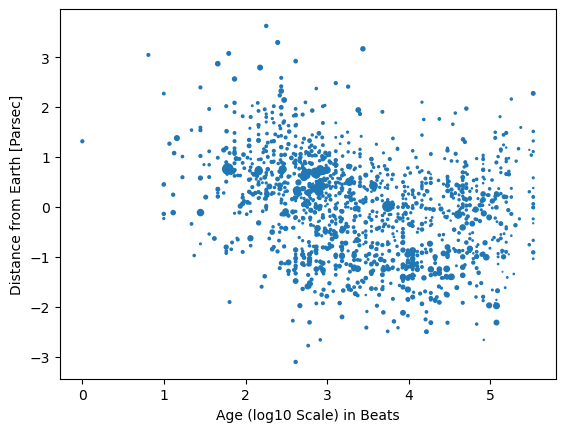

In [163]:
#calculate duration in seconds
bpm = 60  #if bpm = 60, 1 beat = 1 sec 
duration_sec = duration_beats*60/bpm #duration in seconds (actually, onset of last note)
print('Duration:', duration_sec, 'seconds')


plt.scatter(years_ago, distances, s=radius)
plt.xlabel('Age (log10 Scale) in Beats')
plt.ylabel('Distance from Earth [Parsec]')
plt.show()

## Normalization and Scaling

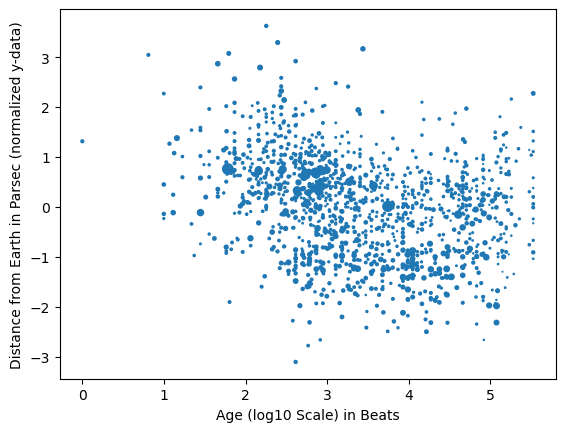

In [164]:

y_data = mapping_function(radius, min(radius), max(radius), 0, 1) #normalize data, so it runs from 0 to 1 

y_scale = 0.5  #lower than 1 to spread out more evenly

y_data = y_data**y_scale

plt.scatter(years_ago, distances, s=radius)
plt.xlabel('Age (log10 Scale) in Beats')
plt.ylabel('Distance from Earth in Parsec (normalized y-data)')
plt.show()

## Pitch Mapping and midi Numbers

In [165]:
import itertools as it
from audiolazy_functions import *

MIDI_A4 = 69 #Note that MIDI note numbers are integers

def str2midi(note_string):
    """Given a note string name (e.g. "Bb4"), returns its MIDI pitch number. (From audiolazy)
    """
    
    data = note_string.strip().lower()
    name2delta = {"c": -9, "d": -7, "e": -5, "f": -4, "g": -2, "a": 0, "b": 2}
    accident2delta = {"b": -1, "#": 1, "x": 2}
    accidents = list(it.takewhile(lambda el: el in accident2delta, data[1:]))
    octave_delta = int(data[len(accidents) + 1:]) - 4
    return (MIDI_A4 +
          name2delta[data[0]] + # Name
          sum(accident2delta[ac] for ac in accidents) + # Accident
          12 * octave_delta # Octave
         )

In [170]:
#from audiolazy import str2midi #import function to convert note names to midi numbers (could also use: midi2str, str2freq, freq2str,freq2midi,midi2freq) https://pypi.org/project/audiolazy/
#removed due to problems importing it with some versions of python

#Instead of C Major, I can try and map onto a different scale --> Let me try to map onto Kalyani Ragam with Sa mapped onto G#

# 4 octaves of Kalyani Ragam
major_note_names = ['Ab2','Bb2','C2','D2','Eb2','F2','G2',
             'Ab3','Bb3','C3','D3','Eb3','F3','G3',
             'Ab4','Bb4','C4','D4','Eb4','F4','G4',
             'Ab5','Bb5','C5','D5','Eb5','F5','G5']

#4 octaves of major pentatonic scale 
pent_note_names = ['Ab2','Bb2','C2','Eb2','F2',
             'Ab3','Bb3','C3','Eb3','F3',
             'Ab4','Bb4','C4','Eb4','F4',
             'Ab5','Bb5','C5','Eb5','F5']


chord_note_names = ['Ab1','Ab2','Eb2',
             'Ab3','C3','Eb3','F3','G3',
             'Bb4','C4','Eb4','F4','G4',
             'Bb5','C5','Eb5','F5','G5',
             'Bb6','C6','D6','Eb6','F6']



note_midis = [str2midi(n) for n in pent_note_names] #make a list of midi note numbers 

#Major scale is not the best choice because some notes are too close to each other. Second best choice 
# would be the Major Pentatonic. --> note that we can also map data to a certain chord

n_notes = len(note_midis)
print('Resolution:',n_notes, 'notes')

Resolution: 20 notes


## Mapping data to Notes

Option 1: We round values to match a traditional keyboard and western standards of pitch

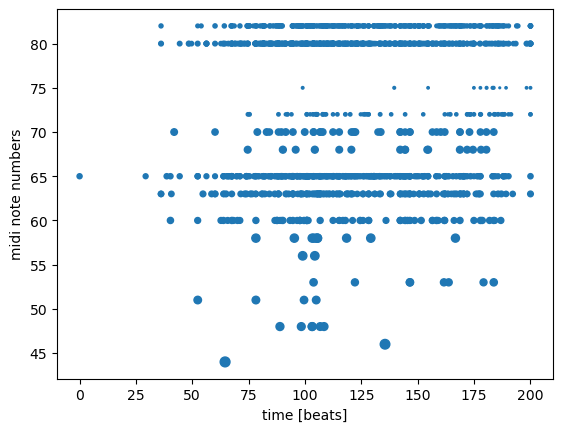

In [171]:
n_structures = len(df)

midi_data = []
for i in range(n_structures): #For every impact, we're running map_value, will take current value, then map it to a new range, then go down the list all the way to zero.
    note_index = round(mapping_function(y_data[i], 0, 1, n_notes-1, 0)) #notice choice of polarity: bigger craters are mapped to lower notes
                                                        #we round the result because it's a list index which must be an integer
                                                        #What happens if you DON'T Round these values? What frequences can you hear? Can h
    midi_data.append(note_midis[note_index])

plt.scatter(t_data, midi_data, s=50*y_data)
plt.xlabel('time [beats]')
plt.ylabel('midi note numbers')
plt.show()

## Map Notes to Velocity

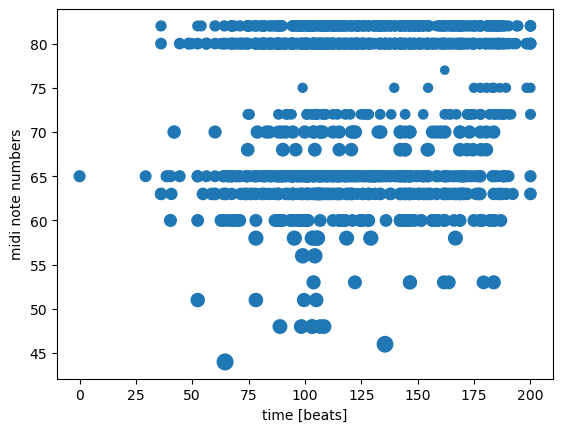

In [172]:
vel_min,vel_max = 35,127   #minimum and maximum note velocity

vel_data = []
for i in range(n_structures):
    note_velocity = round(mapping_function(y_data[i], 0, 1, vel_min, vel_max)) #bigger craters will be louder
                                                                #we round here because note velocites are integers
    vel_data.append(note_velocity)
    
plt.scatter(t_data, midi_data, s=vel_data)
plt.xlabel('time [beats]')
plt.ylabel('midi note numbers')
plt.show()

## Save File as MIDI (Check to see if it's saved onto computer!) and Play it in Notebook!

In [173]:
%pip install MIDIUtil

import sys
print(sys.executable)

from midiutil import MIDIFile #import library to make midi file, https://midiutil.readthedocs.io/en/1.2.1/
    
#create midi file object, add tempo
gaia_midi_file = MIDIFile(1) #one track 
gaia_midi_file.addTempo(track=0, time=0, tempo=bpm) 

#add midi notes
for i in range(n_structures):
    gaia_midi_file.addNote(track=0, channel=0, pitch=midi_data[i], time=t_data[i], duration=2, volume=vel_data[i])

#create and save the midi file itself
with open(file + '.mid', "wb") as f:
    gaia_midi_file.writeFile(f) 

Note: you may need to restart the kernel to use updated packages.
c:\Users\Owner\anaconda3\python.exe


In [ ]:
import sys 
!{sys.executable} -m pip install --quiet "pygame"  #install pygame with pip
#or use this if you installed python with anaconda
#conda install --yes --prefix {sys.prefix} pygame

import pygame #import library for playing midi files, https://pypi.org/project/pygame/

pygame.init()
pygame.mixer.music.load(file + '.mid')
pygame.mixer.music.play()

In [ ]:
pygame.mixer.music.stop()